In [1]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

%matplotlib ipympl

In [2]:
# 학습 데이터 생성
bias = 100
X0, y, w = make_regression(
    n_samples=100, n_features=2, bias=bias,
    noise=10, coef=True, random_state=1)

# Feature Augmentation
X = np.hstack([np.ones((X0.shape[0], 1)), X0])

print("이론적 관계:")
print("y = %.2f + %.2f*x1 + %.2f*x2" % (bias, w[0], w[1]))

이론적 관계:
y = 100.00 + 32.27*x1 + 86.45*x2


In [3]:
print(X.shape)

(100, 3)


In [4]:
# ordinary least squares (OLS) solution
w = np.linalg.inv(X.T @ X) @ X.T @ y
print("추정한 관계:")
print("y = %.2f + %.2f*x1 + %.2f*x2" % (w[0], w[1], w[2]))

추정한 관계:
y = 100.73 + 31.31*x1 + 83.68*x2


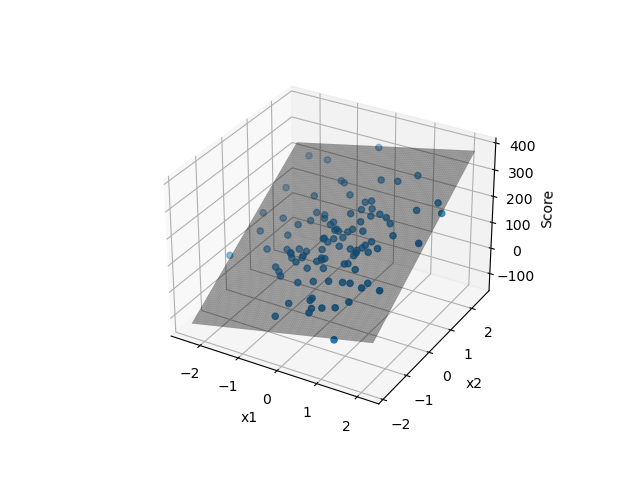

In [5]:
# 그래프 출력
X1_new = np.linspace(np.min(X0[:,0]), np.max(X0[:,0]), 100)
X2_new = np.linspace(np.min(X0[:,1]), np.max(X0[:,1]), 100)
m, n = np.meshgrid(X1_new, X2_new)

ax = plt.axes(projection='3d')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('Score')
ax.scatter(X0[:,0], X0[:,1], y)

z = m*w[1] + n*w[2] + w[0]
ax.plot_surface(m, n, z, rstride=1, cstride=1, color='none', alpha=0.4)
plt.show()